### This notebook computes "P1. SPI intensity and frequency (Standarized Precipitation Index)" indicator for the 27 basins of IKI Project

**Created:** 1//12/2026 by Sophia Bakar (sbakar@rti.org)

**Project #:** 0219481  

**Last modified:** 1/15/2026 by Sophia

**Status:** Complete and loaded into the sql database for the baseline and first future scenario.

**QA Status:** reviewed by Jorge Mayo (jmayo@rti.org) on 1/29/2026  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Peligro
 
**Objective:**   

**Compatibility:** 

**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib 
.  
**Further documentation:**  
 
**Inputs:**   

**Outputs:** 
 
**Assumptions:** The annex does not provide guidance for how to classify the frequency of drought months. We use the quartile-based classification approach which is used in P2 to classify the frequency values. This approach needs QC. Also in the pilot the compute the SPI at a grid level, directly from PISCO netcdf, we are using the MAP to do so.
 
**Future work:** 
 
**Notes:** We should be able to use the output from waterALLOC for this, but for now we are calculating SPI by querying the met tables from the modeling grupos databases. 

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import geopandas as gpd
import os
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

In [2]:
# set up user and database path
user = 'jmayo'
#user = 'sbakar'
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
#db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID = 101 #Indicator ID (Peligro = 1 + 0X where X is the Peligro Indicator number) 

# get scenarios from database 
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: apply the same values to all scenarios
scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
scenario_ids

[1, 2]

In [5]:
# define filepaths for input data
subbasins_shapefile = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
#subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

In [6]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).set_index('COMID').to_crs('WGS84')

In [ ]:
# function to query the modeling groups databases for daily precipitation
def get_precipitation(scenarios):
    dfs = []

    for grupo in range(1, 13):
        
        sqlite_path = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite'
        #sqlite_path = f"C:/Users/sbakar/OneDrive - Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite"

        with sqlite3.connect(sqlite_path) as conn:
            for ScnID, scn_info in scenarios.items():

                query = """
                SELECT
                    comid,
                    avg_precip_cm,
                    measured_date
                FROM catchment_met_observations
                WHERE met_source_id = ?;
                """

                met = pd.read_sql_query(
                    query,
                    conn,
                    params=(scn_info['met_source_id'],)
                )

                if met.empty:
                    continue

                met['measured_date'] = pd.to_datetime(met['measured_date'], format='%Y-%m-%d %H:%M:%S %z UTC', errors='coerce' )

                met = met.dropna(subset=['measured_date'])

                # add scenario ID
                met['ScnID'] = ScnID

                dfs.append(met)

    if not dfs:
        return pd.DataFrame(columns=['ScnID', 'comid', 'measured_date', 'avg_precip_cm'])

    df = pd.concat(dfs, ignore_index=True)

    return df[['ScnID', 'comid', 'measured_date', 'avg_precip_cm']]

In [13]:
# define mapping for scenarios and met source IDs in the modeling groups table 
scenarios = {
    1: {"met_source_id": 2},  # Baseline
    2: {"met_source_id": 5},  # Future CMIP6 8.5
}

In [15]:
# get precipitation from the modeling groups database 
precip_df = get_precipitation(scenarios)

In [20]:
# set up precipitation dataframe for SPI calculation
# convert precip from cm to mm
precip_df['avg_precip_mm'] = precip_df['avg_precip_cm'] * 10
precip_df['measured_date'] = pd.to_datetime(precip_df['measured_date'],errors='coerce',utc=True)

# convert daily precip to monthly
precip_df['year_month'] = precip_df['measured_date'].dt.to_period('M')  # e.g., 1981-01

monthly_precip = (precip_df.groupby(['ScnID', 'comid', 'year_month'])['avg_precip_mm'].sum().reset_index())

# convert year_month back to datetime for plotting
monthly_precip['month_start'] = monthly_precip['year_month'].dt.to_timestamp()

C:\Users\jmayo\AppData\Local\Temp\ipykernel_34296\356084222.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  precip_df['year_month'] = precip_df['measured_date'].dt.to_period('M')  # e.g., 1981-01


In [34]:
def calculate_spi(precip_series, window):
    rolling = precip_series.rolling(window=window, min_periods=window).sum()
    rolling_valid = rolling.dropna()

    # Separate zero and non-zero precipitation
    non_zero = rolling_valid[rolling_valid > 0]
    q = 1 - len(non_zero) / len(rolling_valid)

    # Fit gamma to non-zero values
    shape, loc, scale_param = gamma.fit(non_zero, floc=0)

    # Gamma CDF for all values
    cdf_gamma = gamma.cdf(rolling, shape, loc=0, scale=scale_param)

    # Mixed distribution
    cdf = q + (1 - q) * cdf_gamma
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)

    spi = norm.ppf(cdf)
    return pd.Series(spi, index=precip_series.index)

In [35]:
def calculate_spi_for_group(group, window):
    group = group.sort_values('month_start').copy()
    group[f'SPI_{window}'] = calculate_spi(group['avg_precip_mm'], window)
    return group

In [51]:
spi_1month = (
    monthly_precip
    .groupby(['ScnID', 'comid'])[['month_start', 'avg_precip_mm']]
    .apply(calculate_spi_for_group, window=1)
    .reset_index()
)

In [52]:
spi_1month

,ScnID,comid,level_2,month_start,avg_precip_mm,SPI_1
0,1,304706900,0,1981-01-01,5.810000,-0.324035
1,1,304706900,1,1981-02-01,93.340000,0.877581
2,1,304706900,2,1981-03-01,200.790000,1.437810
3,1,304706900,3,1981-04-01,128.710000,1.093207
4,1,304706900,4,1981-05-01,0.750000,-0.851910
...,...,...,...,...,...,...
59515,2,305023500,59515,2020-08-01,1.069152,-0.995552
59516,2,305023500,59516,2020-09-01,0.126048,-1.383122
59517,2,305023500,59517,2020-10-01,2.105071,-0.855017
59518,2,305023500,59518,2020-11-01,22.210133,-0.255058


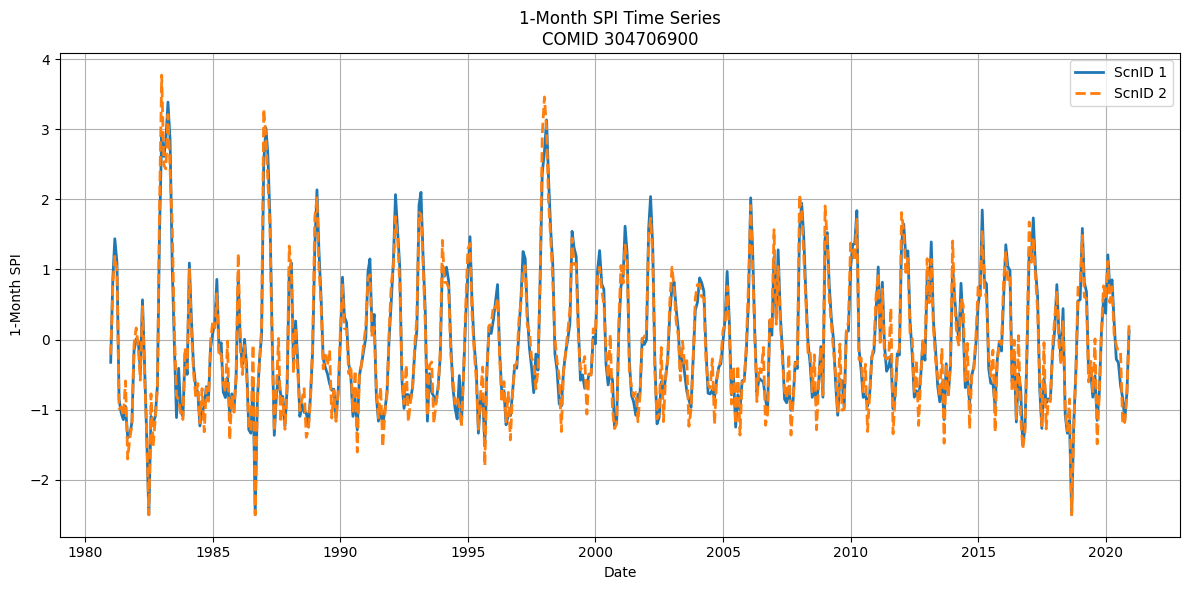

In [38]:
# time series plot for QC

# test COMID
test_comid = '304706900'

# filter SPI data for the test COMID and ScnIDs 1 and 2
spi_comid = spi_1month[
    (spi_1month['comid'].astype(str) == test_comid) &
    (spi_1month['ScnID'].isin([1, 2]))
].sort_values('month_start')

# create the plot
plt.figure(figsize=(12, 6))

# loop over the scenarios for plotting
for scn_id, group in spi_comid.groupby('ScnID'):
    plt.plot(
        group['month_start'],
        group['SPI_1'],
        label=f'ScnID {scn_id}',
        linewidth=2,
        linestyle='-' if scn_id == 1 else '--'
    )

plt.xlabel('Date')
plt.ylabel('1-Month SPI')
plt.title(f'1-Month SPI Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
def classify_spi_intensity(spi):
    if spi < -2.0:
        return 4  # eextremadamente seco
    elif spi < -1.5:
        return 3  # severamente seco
    elif spi < -1.0:
        return 2  # moderadamente seco
    else:
        return 1  # sin sequía o normal (leve)

In [54]:
# apply categorization to SPI values
spi_1month['Intensity'] = spi_1month['SPI_1'].apply(classify_spi_intensity)

In [ ]:
# 1. Identify drought events (SPI-1 < -1)
spi_1month['Drought_event'] = spi_1month['SPI_1'] < -1.0

,ScnID,comid,level_2,month_start,avg_precip_mm,SPI_1,Intensity,Drought_event
0,1,304706900,0,1981-01-01,5.810000,-0.324035,1,False
1,1,304706900,1,1981-02-01,93.340000,0.877581,1,False
2,1,304706900,2,1981-03-01,200.790000,1.437810,1,False
3,1,304706900,3,1981-04-01,128.710000,1.093207,1,False
4,1,304706900,4,1981-05-01,0.750000,-0.851910,1,False
...,...,...,...,...,...,...,...,...
59515,2,305023500,59515,2020-08-01,1.069152,-0.995552,1,False
59516,2,305023500,59516,2020-09-01,0.126048,-1.383122,2,True
59517,2,305023500,59517,2020-10-01,2.105071,-0.855017,1,False
59518,2,305023500,59518,2020-11-01,22.210133,-0.255058,1,False


In [73]:
# 2. Compute frequency ratio by ScnID and comid
freq_df = (
    spi_1month
    .groupby(['ScnID', 'comid'])
    .agg(
        drought_months=('Drought_event', 'sum'),
        total_months=('Drought_event', 'count')
    )
    .reset_index()
)

In [74]:
freq_df['Frequency_ratio'] = freq_df['drought_months'] / freq_df['total_months']

In [75]:
freq_df

,ScnID,comid,drought_months,total_months,Frequency_ratio
0,1,304706900,62,480,0.129167
1,1,304716800,54,480,0.112500
2,1,304721900,95,480,0.197917
3,1,304724000,59,480,0.122917
4,1,304724100,94,480,0.195833
...,...,...,...,...,...
119,2,304962200,77,480,0.160417
120,2,304995600,66,480,0.137500
121,2,304995700,65,480,0.135417
122,2,305023400,61,480,0.127083


In [76]:
freq_df['Frequency_ratio'].min(), freq_df['Frequency_ratio'].max()

(np.float64(0.10416666666666667), np.float64(0.23958333333333334))

In [77]:
# 3. Classify frequency ratio into hazard categories
# (physical/interpretative thresholds)
def classify_frequency_ratio(fr):
    if fr >= 0.40:
        return 4  # Muy Alta (≥ 40% del tiempo)
    elif fr >= 0.25:
        return 3  # Alta
    elif fr >= 0.10:
        return 2  # Media
    else:
        return 1  # Baja

In [78]:
freq_df['Frequency_class'] = freq_df['Frequency_ratio'].apply(classify_frequency_ratio)

In [83]:
# 4. Merge frequency info back with intensity data
hazard_base = freq_df.merge(
    spi_1month,
    on=['ScnID', 'comid'],
    how='left'
)

In [85]:
# 5. Hazard matrix (Frequency x Intensity)
hazard_matrix = {
    4: {1: "Medio", 2: "Alto", 3: "Muy alto", 4: "Muy alto"},
    3: {1: "Bajo",  2: "Medio", 3: "Alto",     4: "Alto"},
    2: {1: "Bajo",  2: "Bajo",  3: "Medio",    4: "Medio"},
    1: {1: "Bajo",  2: "Bajo",  3: "Medio",    4: "Medio"},
}

hazard_to_val = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3,
    "Muy alto": 4
}

In [87]:
hazard_to_val

{'Bajo': 1, 'Medio': 2, 'Alto': 3, 'Muy alto': 4}

In [88]:
# 6. Compute final hazard category and value
def compute_hazard(freq_class, intens_class):
    return hazard_matrix[freq_class][intens_class]

hazard_base['Hazard_category'] = hazard_base.apply(
    lambda r: compute_hazard(r['Frequency_class'], r['Intensity']),
    axis=1
)

In [90]:
hazard_base['Hazard_value'] = hazard_base['Hazard_category'].map(hazard_to_val)

In [91]:
hazard_base

,ScnID,comid,drought_months,total_months,Frequency_ratio,Frequency_class,level_2,month_start,avg_precip_mm,SPI_1,Intensity,Drought_event,Hazard_category,Hazard_value
0,1,304706900,62,480,0.129167,2,0,1981-01-01,5.810000,-0.324035,1,False,Bajo,1
1,1,304706900,62,480,0.129167,2,1,1981-02-01,93.340000,0.877581,1,False,Bajo,1
2,1,304706900,62,480,0.129167,2,2,1981-03-01,200.790000,1.437810,1,False,Bajo,1
3,1,304706900,62,480,0.129167,2,3,1981-04-01,128.710000,1.093207,1,False,Bajo,1
4,1,304706900,62,480,0.129167,2,4,1981-05-01,0.750000,-0.851910,1,False,Bajo,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59515,2,305023500,66,480,0.137500,2,59515,2020-08-01,1.069152,-0.995552,1,False,Bajo,1
59516,2,305023500,66,480,0.137500,2,59516,2020-09-01,0.126048,-1.383122,2,True,Bajo,1
59517,2,305023500,66,480,0.137500,2,59517,2020-10-01,2.105071,-0.855017,1,False,Bajo,1
59518,2,305023500,66,480,0.137500,2,59518,2020-11-01,22.210133,-0.255058,1,False,Bajo,1


In [92]:
hazard_base['Hazard_category'].value_counts()

Hazard_category
Bajo     57879
Medio     1641
Name: count, dtype: int64

In [ ]:
## ADD CODE TO PLOT FOR QC

In [32]:
#insert the results into the sqlite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for _, row in hazard_base.iterrows():
    rows_to_insert.append((
        int(row['ScnID']),
        IndID,
        int(row['comid']),
        int(row['Hazard_value'])
    ))

insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [34]:
# check that the expected min and max values in the indicators table match the calculated values
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats_by_scenario = (
    hazard_base
    .groupby('ScnID')['Hazard_value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Value values by scenario ===")
print(value_stats_by_scenario)

df_check = pd.DataFrame(
    rows_to_insert,
    columns=['ScnID', 'IndID', 'COMID', 'Value']
)

duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 101  Min: 1, Max: 4

=== Value values by scenario ===
   ScnID  min  max    count
0      1    1    4  1754400
1      2    1    4  1465920

Duplicates in rows_to_insert:
         ScnID  IndID      COMID  Value
1            1    101  304273900      1
2            1    101  304273900      1
3            1    101  304273900      1
4            1    101  304273900      2
5            1    101  304273900      1
...        ...    ...        ...    ...
3220315      2    101  320254600      1
3220316      2    101  320254600      1
3220317      2    101  320254600      1
3220318      2    101  320254600      1
3220319      2    101  320254600      1

[3213611 rows x 4 columns]


In [35]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()